In [2]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [3]:
# LOAD DATASET

df = pd.read_csv(
    "Credit_Card.csv",
    sep=";"
)

print(df.shape)

df.head()

(34788, 30)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


In [4]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 34788 entries, 0 to 34787
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          34788 non-null  int64  
 1   LIMIT_BAL                   33079 non-null  float64
 2   SEX                         33021 non-null  float64
 3   EDUCATION                   33054 non-null  float64
 4   MARRIAGE                    33055 non-null  float64
 5   AGE                         33033 non-null  float64
 6   PAY_0                       34788 non-null  int64  
 7   PAY_2                       34788 non-null  int64  
 8   PAY_3                       34788 non-null  int64  
 9   PAY_4                       34788 non-null  int64  
 10  PAY_5                       34788 non-null  int64  
 11  PAY_6                       34788 non-null  int64  
 12  BILL_AMT1                   34788 non-null  float64
 13  BILL_AMT2                   34788 non-null

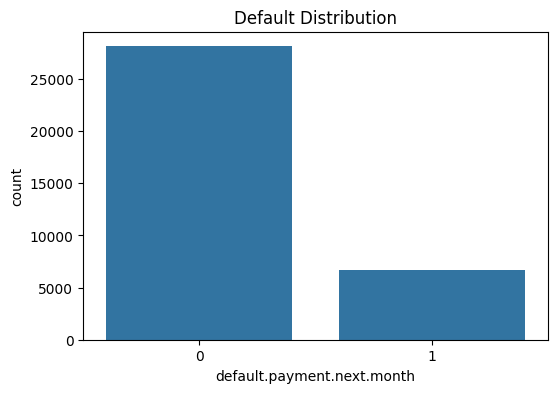

default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64


In [5]:
# TASK 1 – EDA
# Target Variable Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='default.payment.next.month',
    data=df
)

plt.title("Default Distribution")
plt.show()

print(
    df['default.payment.next.month']
    .value_counts(normalize=True)*100
)

In [6]:
# Descriptive Statistics
features = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT_SUM'
]

print(df[features].describe())

          LIMIT_BAL           AGE  BILL_AMT_SUM
count  3.307900e+04  33033.000000  3.478800e+04
mean   1.846690e+05     35.518300  2.948152e+05
std    2.359319e+05      9.236783  5.718073e+05
min    1.000000e+04     21.000000 -3.362590e+05
25%    6.000000e+04     28.000000  2.973825e+04
50%    1.400000e+05     34.000000  1.290370e+05
75%    2.400000e+05     41.000000  3.502095e+05
max    5.600000e+06     79.000000  2.129266e+07


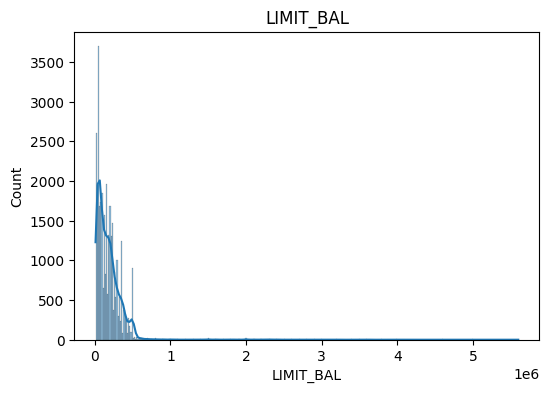

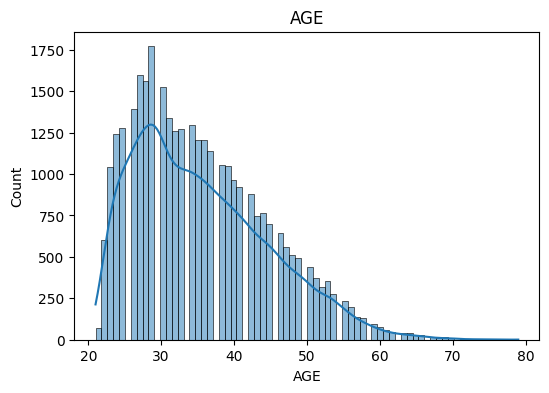

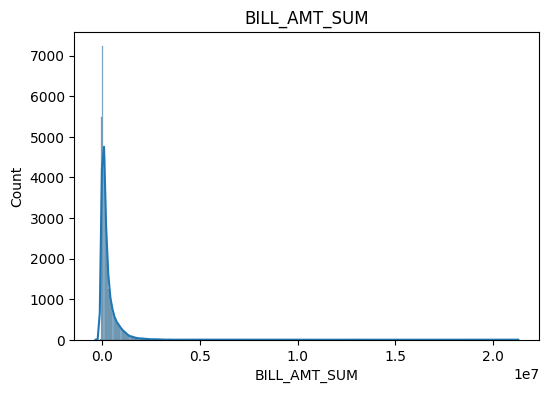

In [7]:
# Histograms
for col in [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT_SUM'
]:
    
    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

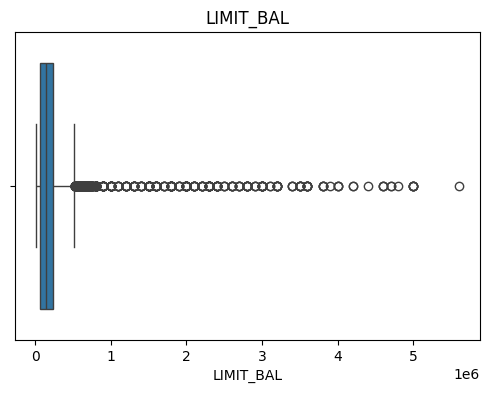

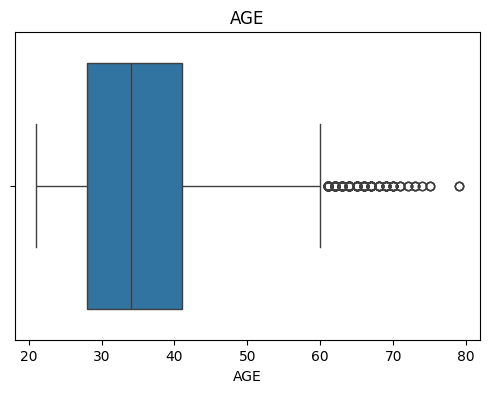

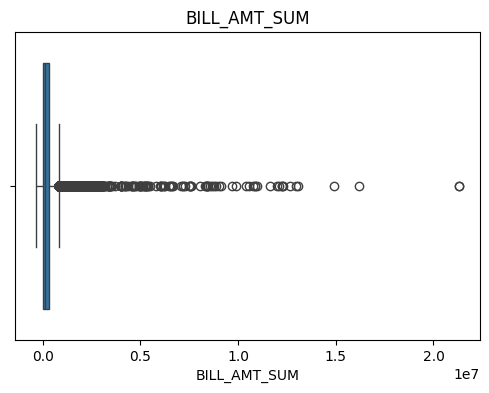

In [8]:
# Boxplots
for col in [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT_SUM'
]:
    
    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

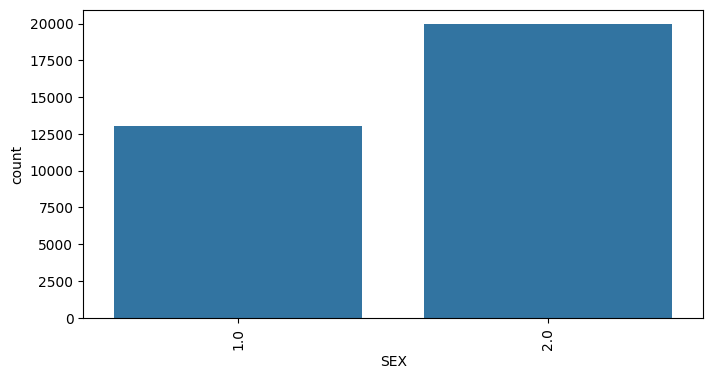

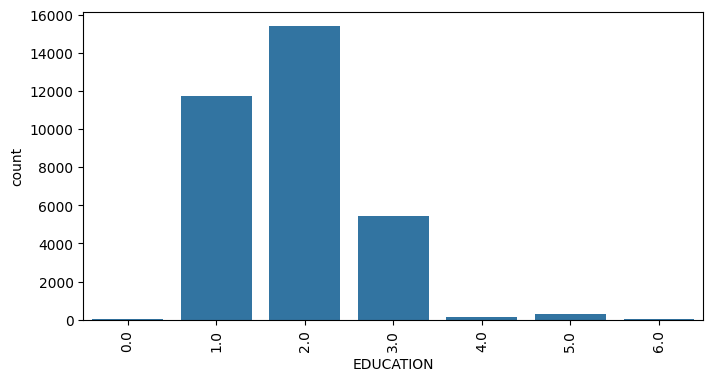

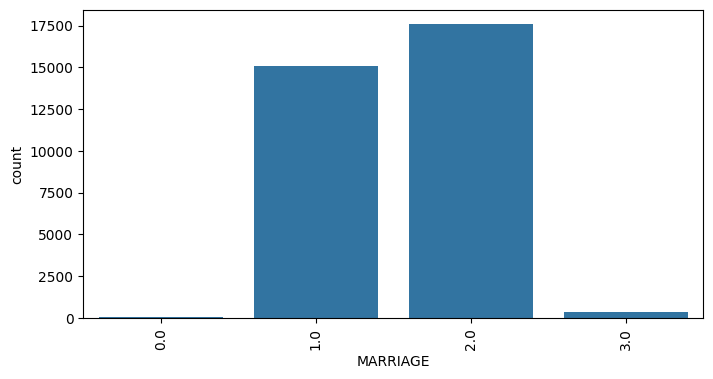

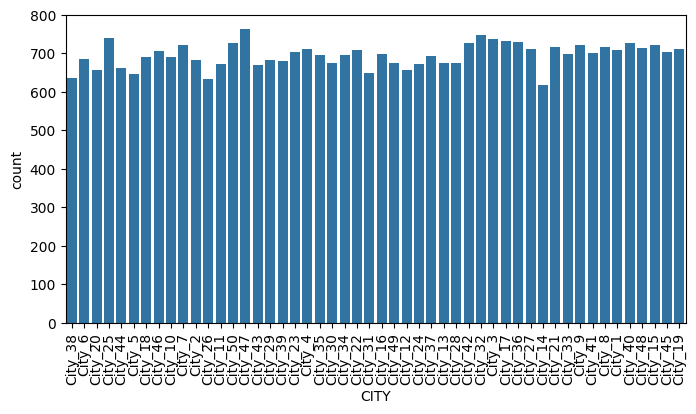

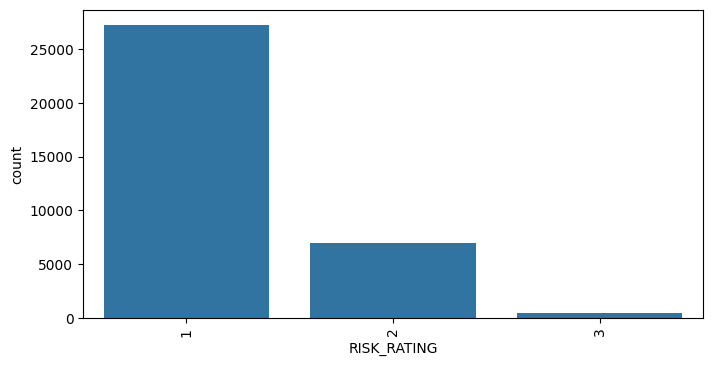

In [9]:
# Categorical Variables
categorical_cols = [
    'SEX',
    'EDUCATION',
    'MARRIAGE',
    'CITY',
    'RISK_RATING'
]

for col in categorical_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        x=col,
        data=df
    )

    plt.xticks(rotation=90)

    plt.show()

In [10]:
# TASK 2 – DATA PREPARATION
# Missing Values

missing = pd.DataFrame(
    df.isnull().sum(),
    columns=['Missing']
)

print(
    missing[missing['Missing'] > 0]
)

               Missing
LIMIT_BAL         1709
SEX               1767
EDUCATION         1734
MARRIAGE          1733
AGE               1755
PAY_AMT1          1725
PAY_AMT2          1744
LIMIT_BAL_LOG     1709


In [11]:
# Fix Corrupted Columns
# risk_leak

df['risk_leak'] = (
    df['risk_leak']
    .astype(str)
    .str.replace(
        r'(?<=\d)\.(?=\d{3,})',
        '',
        regex=True
    )
)

df['risk_leak'] = pd.to_numeric(
    df['risk_leak'],
    errors='coerce'
)

In [12]:
# LIMIT_BAL_LOG

df['LIMIT_BAL_LOG'] = (
    df['LIMIT_BAL_LOG']
    .astype(str)
    .str.replace(
        r'(?<=\d)\.(?=\d{3,})',
        '',
        regex=True
    )
)

df['LIMIT_BAL_LOG'] = pd.to_numeric(
    df['LIMIT_BAL_LOG'],
    errors='coerce'
)

In [13]:
# Imputation
# Numerical

num_cols = df.select_dtypes(
    include=np.number
).columns

num_imputer = SimpleImputer(
    strategy='median'
)

df[num_cols] = num_imputer.fit_transform(
    df[num_cols]
)

In [14]:
# Categorical

cat_cols = df.select_dtypes(
    include='object'
).columns

cat_imputer = SimpleImputer(
    strategy='most_frequent'
)

df[cat_cols] = cat_imputer.fit_transform(
    df[cat_cols]
)

In [15]:
# Encode CITY
le = LabelEncoder()

df['CITY'] = le.fit_transform(
    df['CITY']
)

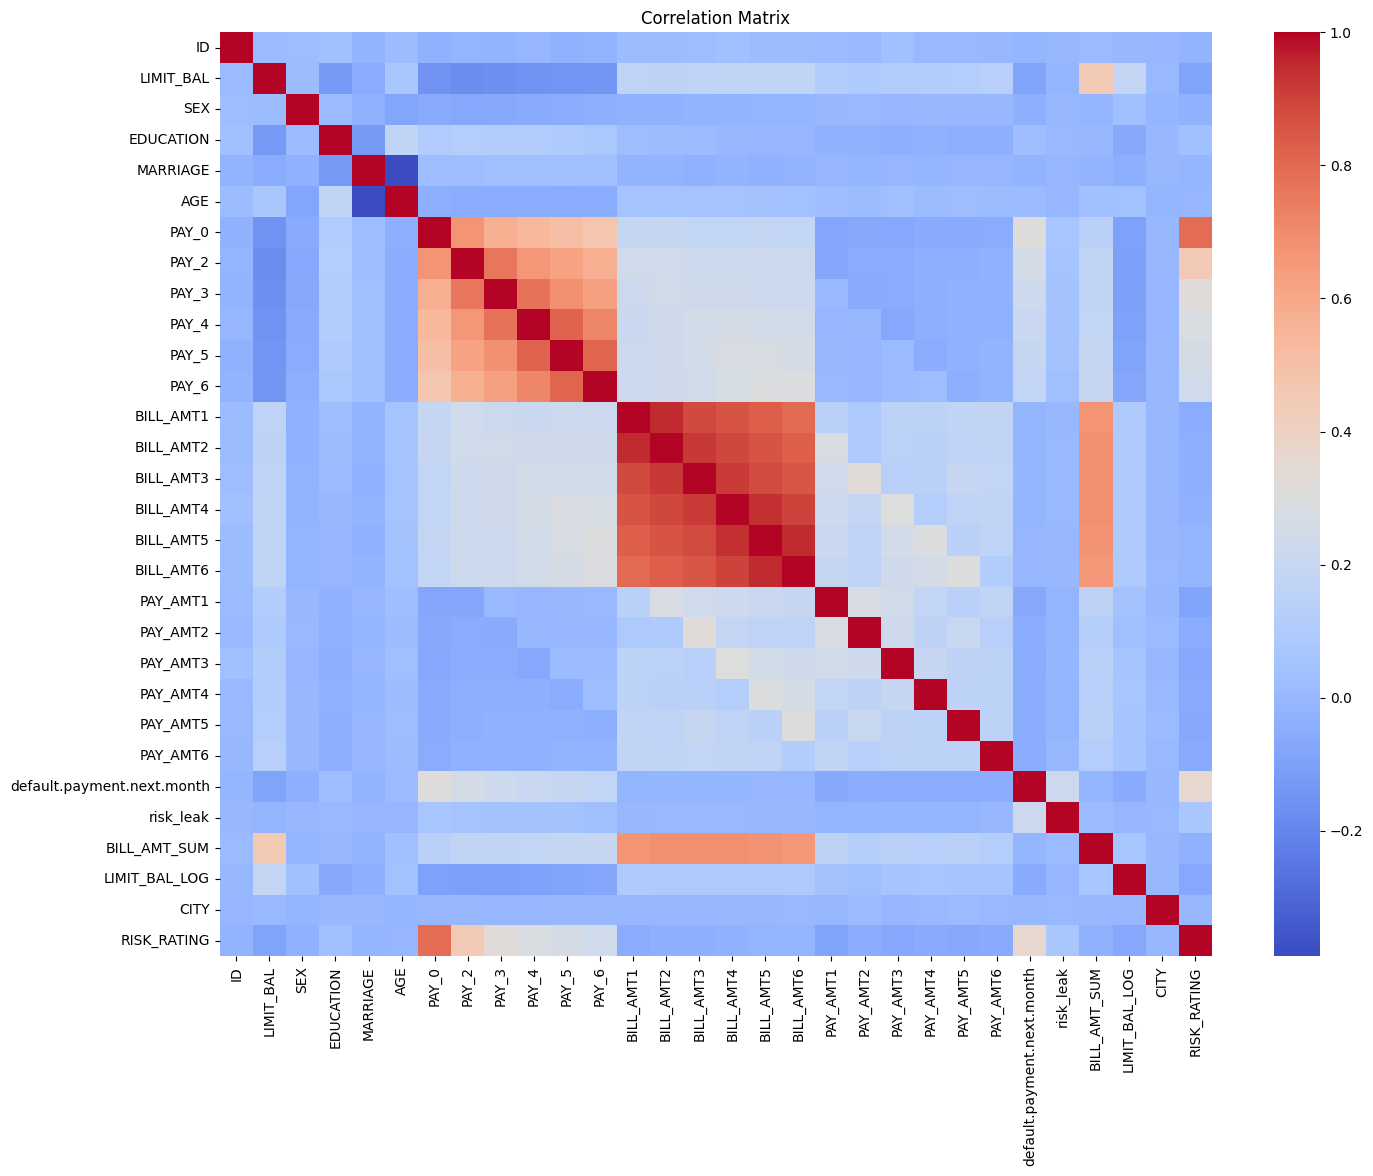

In [16]:
# Correlation Heatmap
plt.figure(
    figsize=(16,12)
)

sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    cmap='coolwarm'
)

plt.title(
    "Correlation Matrix"
)

plt.show()

In [17]:
# Feature & Target Split
X = df.drop(
    'default.payment.next.month',
    axis=1
)

y = df[
    'default.payment.next.month'
]

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
# TASK 3 – TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [20]:
# TASK 3 – MODEL TRAINING
models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(probability=True),

    "Gradient Boosting":
        GradientBoostingClassifier()
}

In [21]:
results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    prob = model.predict_proba(
        X_test
    )[:,1]

    results.append({

        "Model":name,

        "Accuracy":
            accuracy_score(
                y_test,
                pred
            ),

        "Precision":
            precision_score(
                y_test,
                pred
            ),

        "Recall":
            recall_score(
                y_test,
                pred
            ),

        "F1":
            f1_score(
                y_test,
                pred
            ),

        "AUC":
            roc_auc_score(
                y_test,
                prob
            )
    })

results_df = pd.DataFrame(
    results
)

print(results_df)

                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.825525   0.595432  0.274230  0.375514  0.810220
1        Decision Tree  0.922966   0.833194  0.746807  0.787639  0.855721
2        Random Forest  0.929003   0.887859  0.719760  0.795021  0.978398
3                  KNN  0.848663   0.656885  0.437265  0.525034  0.801347
4                  SVM  0.857861   0.741525  0.394440  0.514958  0.894697
5    Gradient Boosting  0.929146   0.803184  0.833959  0.818282  0.975528


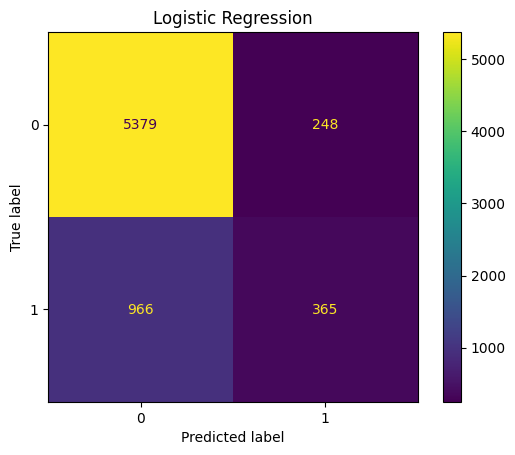

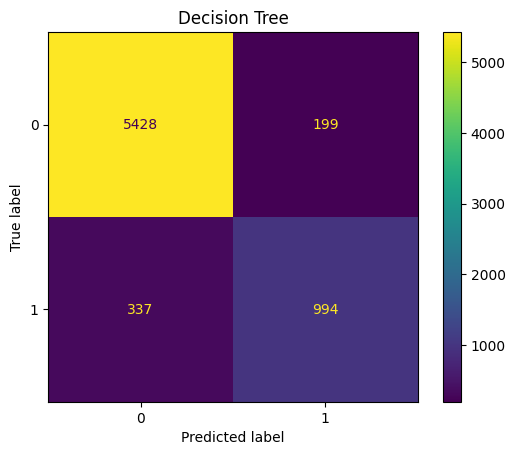

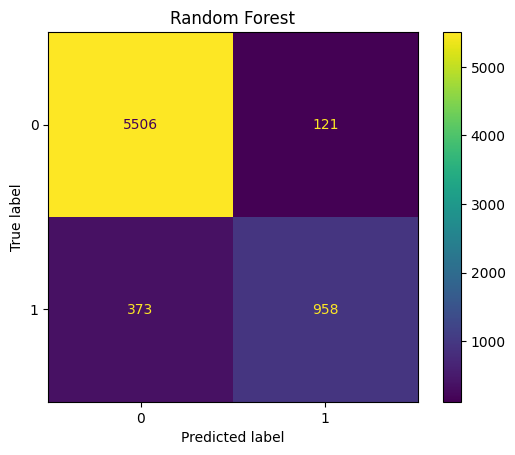

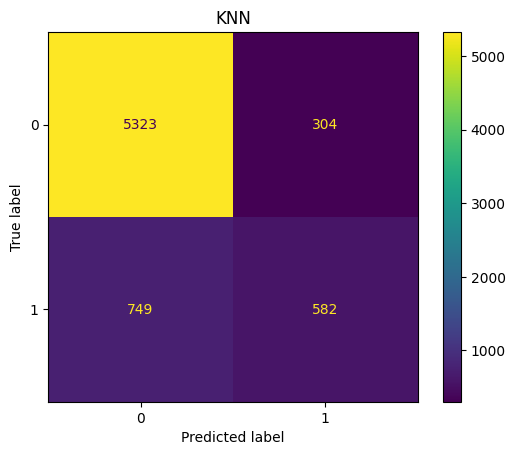

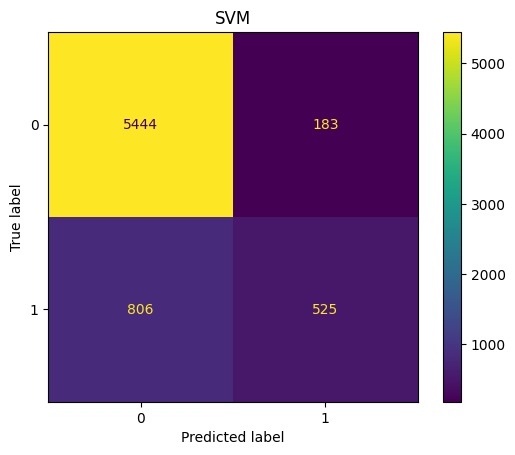

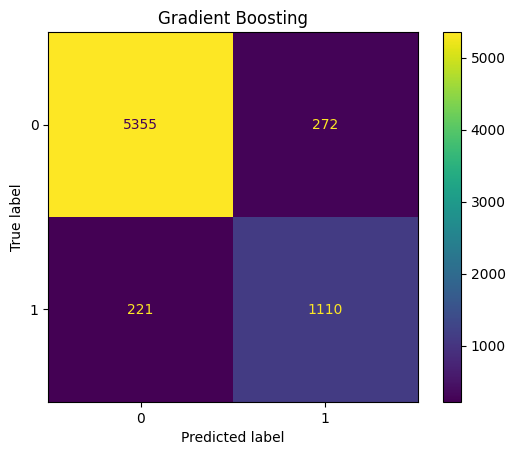

In [22]:
# TASK 4 – Confusion Matrices
for name, model in models.items():

    pred = model.predict(
        X_test
    )

    cm = confusion_matrix(
        y_test,
        pred
    )

    disp = ConfusionMatrixDisplay(
        cm
    )

    disp.plot()

    plt.title(name)

    plt.show()

<Figure size 800x600 with 0 Axes>

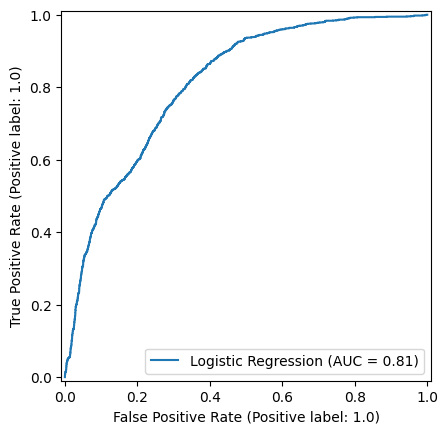

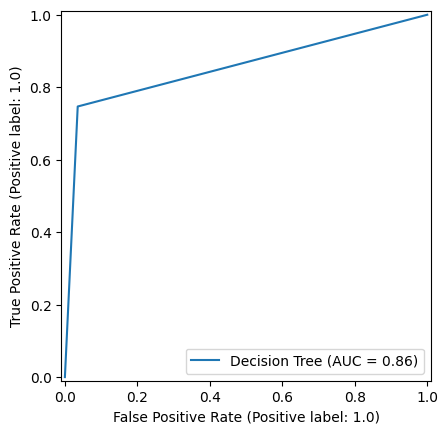

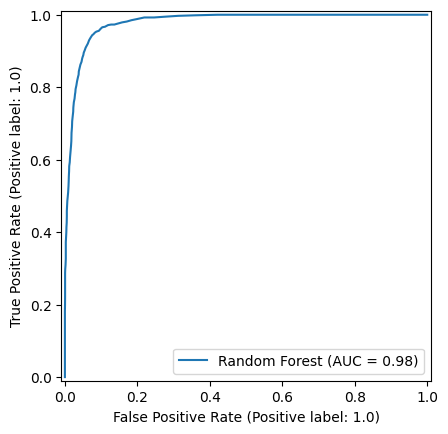

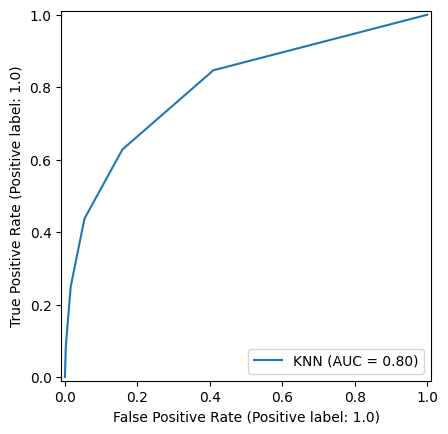

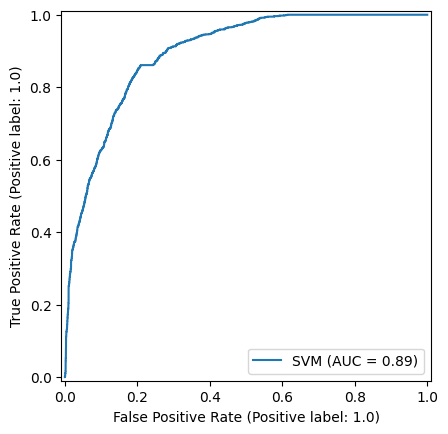

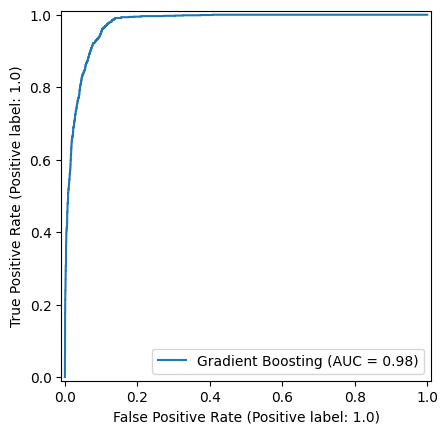

In [23]:
# ROC Curves
plt.figure(figsize=(8,6))

for name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.show()

In [24]:
# TASK 4 – Hyperparameter Tuning
param_grid = {

    'n_estimators':
        [100,200,300],

    'max_depth':
        [5,10,15],

    'min_samples_split':
        [2,5]
}

In [25]:
grid = GridSearchCV(

    RandomForestClassifier(),

    param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

best_rf = grid.best_estimator_

print(
    grid.best_params_
)

{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 300}


In [26]:
pred = best_rf.predict(
    X_test
)

prob = best_rf.predict_proba(
    X_test
)[:,1]

print(
    classification_report(
        y_test,
        pred
    )
)

print(
    roc_auc_score(
        y_test,
        prob
    )
)

              precision    recall  f1-score   support

         0.0       0.93      0.98      0.96      5627
         1.0       0.89      0.70      0.78      1331

    accuracy                           0.93      6958
   macro avg       0.91      0.84      0.87      6958
weighted avg       0.92      0.93      0.92      6958

0.9737252115851754


In [29]:
import shap

In [30]:
explainer = shap.TreeExplainer(
    best_rf
)

shap_values = explainer.shap_values(
    X_test
)

In [32]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [33]:
print(np.array(shap_values).shape)

(6958, 29, 2)


In [34]:
print(shap_values.shape)

(6958, 29, 2)


In [ ]:
# Convert your test data back to a DataFrame
X_test_df = pd.DataFrame(
    X_test,
    columns=X.columns
)

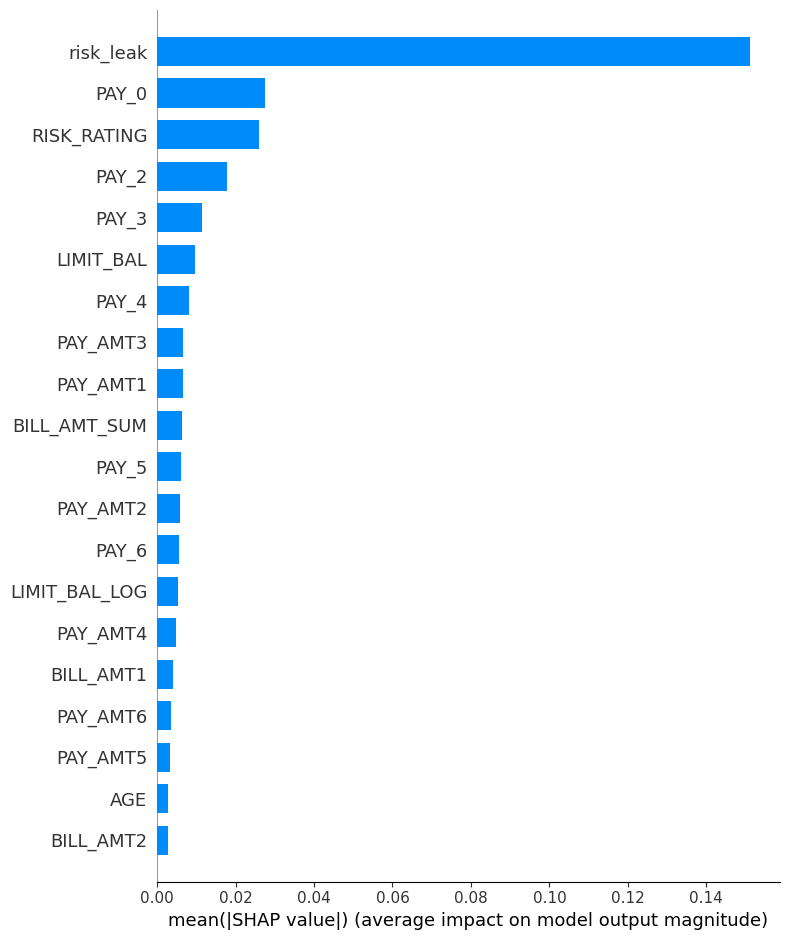

In [ ]:
# SHAP Bar Plot
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_df,
    plot_type="bar"
)

In [ ]:
# SHAP Waterfall Plot (Individual Prediction)
sample = 0

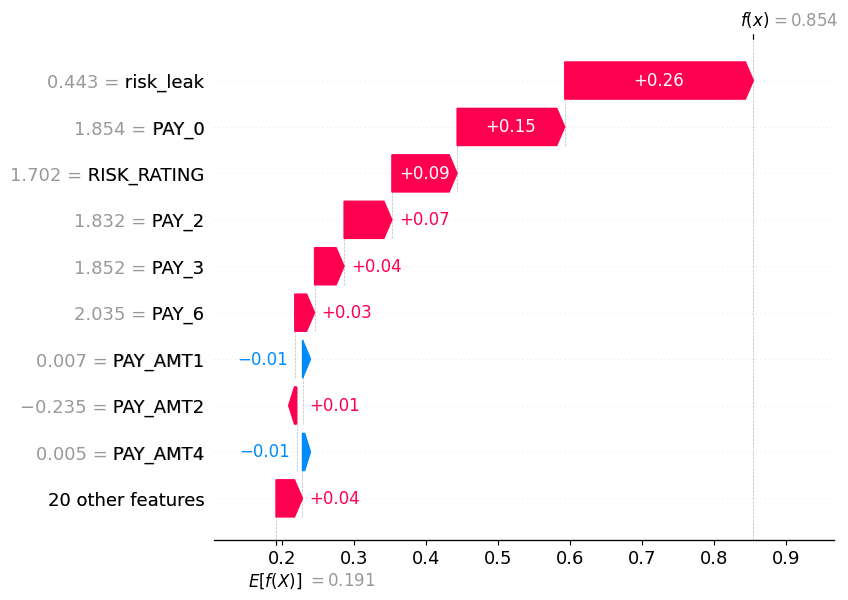

In [39]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_df.iloc[sample],
        feature_names=X.columns
    )
)

In [40]:
# Top Feature Importance
importance = pd.DataFrame({

    "Feature":
        X.columns,

    "Importance":
        best_rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(
    importance.head(15)
)

         Feature  Importance
24     risk_leak    0.443289
6          PAY_0    0.068589
28   RISK_RATING    0.048826
7          PAY_2    0.039031
8          PAY_3    0.024108
0             ID    0.023553
12     BILL_AMT1    0.022015
25  BILL_AMT_SUM    0.021538
18      PAY_AMT1    0.020391
13     BILL_AMT2    0.018616
5            AGE    0.018436
1      LIMIT_BAL    0.018342
20      PAY_AMT3    0.017758
27          CITY    0.017641
19      PAY_AMT2    0.017614


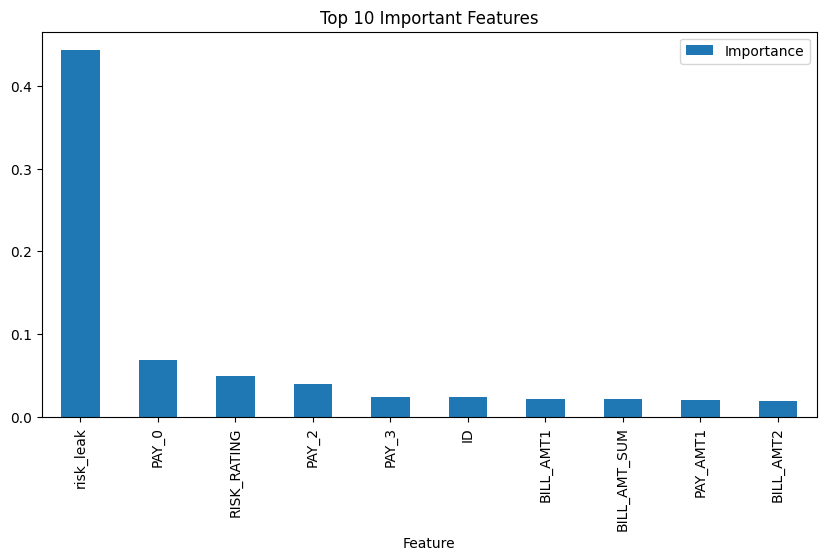

In [41]:
# TASK 5 – Future Work Visual
importance.head(10).plot(

    x='Feature',

    y='Importance',

    kind='bar',

    figsize=(10,5)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()